<a href="https://colab.research.google.com/github/Mayar215999/data-science-project/blob/main/League_of_Legends_Match_Predictor_Deep_learning_M7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deep Neural Network for Breast Cancer Classification
Setup
For this lab, we will be using the following libraries:

pandas for managing the data.
numpy for mathematical operations.
matplotlib for additional plotting tools.
sklearn for machine learning and machine-learning-pipeline related functions.
torch for building and training the deep neural network.
ucimlrepo for loading the dataset.
Installing Required Libraries


In [1]:
%pip install pandas==2.2.2
%pip install numpy==1.26.4
%pip install matplotlib==3.8.0
%pip install scikit-learn==1.5.0
%pip install torch==2.3.1
%pip install ucimlrepo==0.0.7

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 46.6 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 74.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
^C
^C
^C


Load the Data
Breast Cancer Wisconsin (Diagnostic)
The Breast Cancer Wisconsin (Diagnostic) dataset is a classic dataset used for classification tasks. It contains 569 samples of breast cancer cells, each with 30 features. The dataset is divided into two classes: benign and malignant. The goal is to classify the breast cancer cells into one of the two classes.

This dataset is free to use and is licensed under a Creative Commons Attribution 4.0 International (CC BY 4.0) license.

First, we need to load our dataset and take a look at its structure.

In [2]:
!pip install ucimlrepo==0.0.7

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# print the first few rows of the data
display(X.head())

# print the first few rows of the target
display(y.head())

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,Diagnosis
0,M
1,M
2,M
3,M
4,M


In [4]:
display(f'X shape: {X.shape}')
display(f'y shape: {y.shape}')


'X shape: (569, 30)'

'y shape: (569, 1)'

As we can see, the dataset has 569 samples and 30 features. The target variable is the diagnosis column, which contains the class labels for each sample. The class labels are either 'M' (malignant) or 'B' (benign).

We will then check the distribution of the target variable.

In [5]:
display(y['Diagnosis'].value_counts())

,count
Diagnosis,
B,357
M,212


Note that the dataset is imbalanced, with more benign samples than malignant samples.

We will now process the data. Randomly choose 200 samples in 'M' (malignant) and 200 samples in 'B' (benign).

In [6]:
import pandas as pd

# Combine features and target into a single DataFrame for easier manipulation
data = pd.concat([X, y], axis=1)

# Separate the two classes
data_B = data[data['Diagnosis'] == 'B']
data_M = data[data['Diagnosis'] == 'M']

# Select 200 samples from each class
data_B = data_B.sample(n=200, random_state=42)
data_M = data_M.sample(n=200, random_state=42)

# Combine the two classes
balanced_data = pd.concat([data_B, data_M])

display(balanced_data['Diagnosis'].value_counts())

,count
Diagnosis,
B,200
M,200


There are 200 samples in each class, with a total of 400 samples. It means that the dataset is balanced.

We will use 80% of the samples for training and 20% for testing.


Data Preprocessing
Before feeding the data into our neural network, we need to preprocess it. This involves separating the features and labels, splitting the data into training and test sets, and standardizing the feature values.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# Separate features and targets
X = balanced_data.drop('Diagnosis', axis=1)
y = balanced_data['Diagnosis']

# Convert the targets to binary labels
y = y.map({'B': 0, 'M': 1})

display(X)
display(y)

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
395,14.060,17.18,89.75,609.1,0.08045,0.05361,0.026810,0.03251,0.1641,0.05764,...,14.92,25.34,96.42,684.5,0.10660,0.12310,0.08460,0.07911,0.2523,0.06609
110,9.777,16.99,62.50,290.2,0.10370,0.08404,0.043340,0.01778,0.1584,0.07065,...,11.05,21.47,71.68,367.0,0.14670,0.17650,0.13000,0.05334,0.2533,0.08468
481,13.900,19.24,88.73,602.9,0.07991,0.05326,0.029950,0.02070,0.1579,0.05594,...,16.41,26.42,104.40,830.5,0.10640,0.14150,0.16730,0.08150,0.2356,0.07603
493,12.460,12.83,78.83,477.3,0.07372,0.04043,0.007173,0.01149,0.1613,0.06013,...,13.19,16.36,83.24,534.0,0.09439,0.06477,0.01674,0.02680,0.2280,0.07028
136,11.710,16.67,74.72,423.6,0.10510,0.06095,0.035920,0.02600,0.1339,0.05945,...,13.33,25.48,86.16,546.7,0.12710,0.10280,0.10460,0.06968,0.1712,0.07343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,15.320,17.27,103.20,713.3,0.13350,0.22840,0.244800,0.12420,0.2398,0.07596,...,17.73,22.66,119.80,928.8,0.17650,0.45030,0.44290,0.22290,0.3258,0.11910
328,16.270,20.71,106.90,813.7,0.11690,0.13190,0.147800,0.08488,0.1948,0.06277,...,19.28,30.38,129.80,1121.0,0.15900,0.29470,0.35970,0.15830,0.3103,0.08200
199,14.450,20.22,94.49,642.7,0.09872,0.12060,0.118000,0.05980,0.1950,0.06466,...,18.33,30.12,117.90,1044.0,0.15520,0.40560,0.49670,0.18380,0.4753,0.10130
194,14.860,23.21,100.40,671.4,0.10440,0.19800,0.169700,0.08878,0.1737,0.06672,...,16.08,27.78,118.60,784.7,0.13160,0.46480,0.45890,0.17270,0.3000,0.08701


,Diagnosis
395,0
110,0
481,0
493,0
136,0
...,...
257,1
328,1
199,1
194,1


The data will be split into 80% training and 20% test sets.

We then print the shapes of the training and test sets to verify that the data has been split correctly.

In [8]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

display(f'X_train shape: {X_train.shape}')
display(f'y_train shape: {y_train.shape}')
display(f'X_test shape: {X_test.shape}')
display(f'y_test shape: {y_test.shape}')

'X_train shape: (320, 30)'

'y_train shape: (320,)'

'X_test shape: (80, 30)'

'y_test shape: (80,)'

Then we standardize the feature values using the StandardScaler from scikit-learn.

Standardizing the data involves transforming the features so that they have a mean of 0 and a standard deviation of 1. This helps in ensuring that all features contribute equally to the result and helps the model converge faster during training.

Fitting the Scaler: We calculate the mean and standard deviation for each feature in the training set using the fit method of the StandardScaler.
Transforming the Training Data: We apply the standardization to the training data using the transform method, which scales the features accordingly.
Transforming the Test Data: We apply the same transformation to the test data using the same scaler. This ensures that both training and test sets are standardized in the same way.
By standardizing the data, we make sure that each feature contributes equally to the training process, which helps in achieving better performance and faster convergence of the neural network model.

Finally, we convert the NumPy arrays to PyTorch tensors.

In [9]:
from torch.utils.data import DataLoader, TensorDataset

# Standardize the data
# Initialize the StandardScaler
scaler = StandardScaler()
# Fit the scaler on the training data and transform it
X_train = scaler.fit_transform(X_train)
# Transform the test data using the same scaler
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

# Create DataLoader for training and test sets
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

Build and Train the Neural Network Model
We will define our neural network architecture, specify the loss function and optimizer, and then train the model.

First, we define the neural network architecture using the nn.Module class in PyTorch. Our model consists of an input layer, one hidden layer, and an output layer with 2 neurons corresponding to the 2 classes.

Below is an example of the neural network model, it has 8 neurons in the input layer, 8 neurons in the hidden layer, and 2 neurons in the output layer.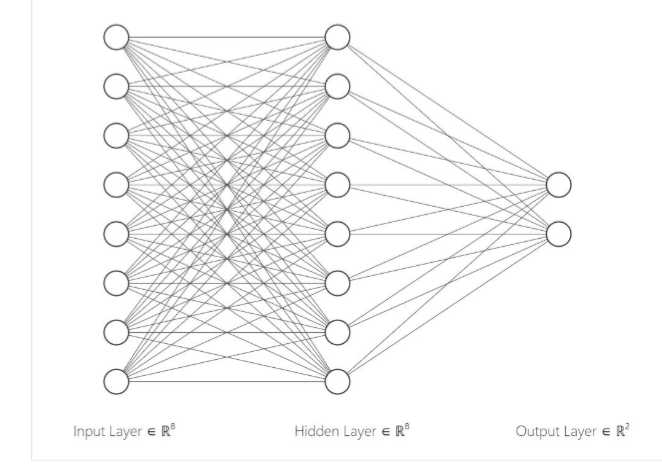

In [10]:
import torch.nn as nn

class ClassificationNet(nn.Module):
    def __init__(self, input_units=30, hidden_units=64, output_units=2):
        super(ClassificationNet, self).__init__()
        self.fc1 = nn.Linear(input_units, hidden_units)
        self.fc2 = nn.Linear(hidden_units, output_units)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the model
model = ClassificationNet(input_units=30, hidden_units=64, output_units=2)

Let us visualize the neural network architecture.

In [11]:
print(model)

ClassificationNet(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)


Then we define the loss function and optimizer. We use the CrossEntropyLoss loss function, which is commonly used for multi-class classification problems. The Adam optimizer is used to update the weights of the neural network during training.

In [12]:
import torch.optim as optim

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Then we can train the model using the training data. We iterate over the training data for a specified number of epochs and update the weights of the neural network using backpropagation.

During training, we calculate the loss at each epoch and print it to monitor the training progress. The loss should decrease over time as the model learns to classify the classes correctly.

Finally, we evaluate the model on the test data to see how well it performs on unseen data.

In [13]:
epochs = 10
train_losses = []
test_losses = []

for epoch in range(epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Evaluation phase on test set
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            test_outputs = model(X_batch)
            loss = criterion(test_outputs, y_batch)
            test_loss += loss.item()

    test_loss /= len(test_loader)
    test_losses.append(test_loss)

    print(f'Epoch [{epoch + 1}/{epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

Epoch [1/10], Train Loss: 0.3255, Test Loss: 0.2004
Epoch [2/10], Train Loss: 0.1254, Test Loss: 0.1423
Epoch [3/10], Train Loss: 0.0938, Test Loss: 0.1212
Epoch [4/10], Train Loss: 0.0826, Test Loss: 0.1148
Epoch [5/10], Train Loss: 0.0759, Test Loss: 0.1071
Epoch [6/10], Train Loss: 0.0704, Test Loss: 0.1015
Epoch [7/10], Train Loss: 0.0636, Test Loss: 0.0980
Epoch [8/10], Train Loss: 0.0591, Test Loss: 0.0978
Epoch [9/10], Train Loss: 0.0534, Test Loss: 0.1008
Epoch [10/10], Train Loss: 0.0524, Test Loss: 0.0972


Visualize the Training and Test Loss
Plotting the loss curves helps us understand the training dynamics of our model.

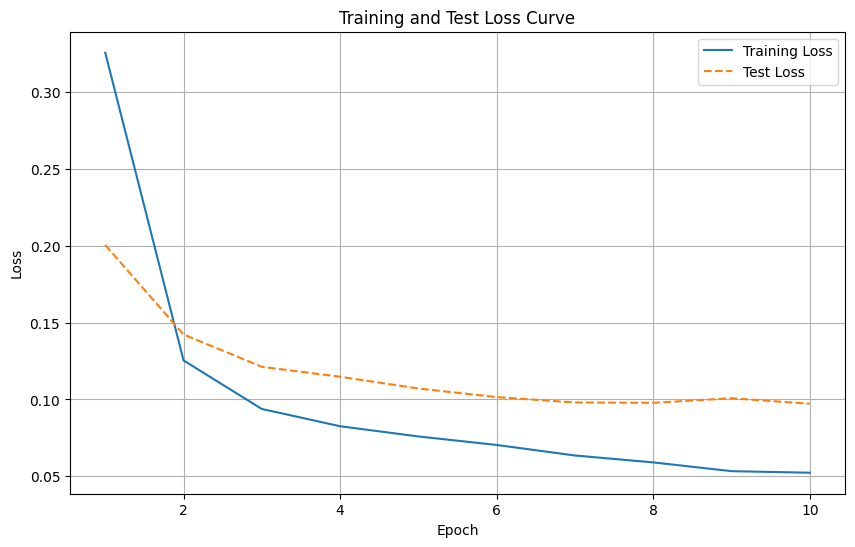

In [14]:
import matplotlib.pyplot as plt

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

Exercises

Exercise 1 - Change to different optimizer: SGD
Stochastic Gradient Descent (SGD) is a widely used optimization algorithm in machine learning and deep learning for training models. It is an iterative method for optimizing a loss function by making small updates to the model parameters in the direction of the negative gradient.

How SGD Works

SGD updates the model's parameters iteratively. The update rule for each parameter
𝜃
 is as follows:

𝜃
=
𝜃
−
𝜂
⋅
∇
𝜃
𝐽
(
𝜃
)

where:

𝜃
 represents the model parameters.
𝜂
 (eta) is the learning rate, which controls the step size of each update.
∇
𝜃
𝐽
(
𝜃
)
 is the gradient of the loss function with respect to the parameter
𝜃
.
PyTorch's torch.optim.SGD

In PyTorch, the torch.optim.SGD optimizer provides several parameters to configure its behavior.

Parameters

params:

The model parameters to optimize.
Typically provided as model.parameters().
lr (learning rate):

A positive float value that controls the step size for each parameter update.
Example: lr=0.01.
momentum (optional):

A float value that accelerates SGD in the relevant direction and dampens oscillations.
Example: momentum=0.9.
weight_decay (optional):

A float value representing the L2 penalty (regularization term) to prevent overfitting.
Example: weight_decay=0.0001.
dampening (optional):

A float value that reduces the effect of the momentum.
Default is 0.
Example Usage

Here’s how you can use torch.optim.SGD with some of these parameters:

import torch.optim as optim

# Define the SGD optimizer
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0001)

Epoch [1/10], Train Loss: 0.6885, Test Loss: 0.6767
Epoch [2/10], Train Loss: 0.6885, Test Loss: 0.6767
Epoch [3/10], Train Loss: 0.6885, Test Loss: 0.6767
Epoch [4/10], Train Loss: 0.6885, Test Loss: 0.6767
Epoch [5/10], Train Loss: 0.6885, Test Loss: 0.6767
Epoch [6/10], Train Loss: 0.6885, Test Loss: 0.6767
Epoch [7/10], Train Loss: 0.6885, Test Loss: 0.6767
Epoch [8/10], Train Loss: 0.6885, Test Loss: 0.6767
Epoch [9/10], Train Loss: 0.6885, Test Loss: 0.6767
Epoch [10/10], Train Loss: 0.6885, Test Loss: 0.6767


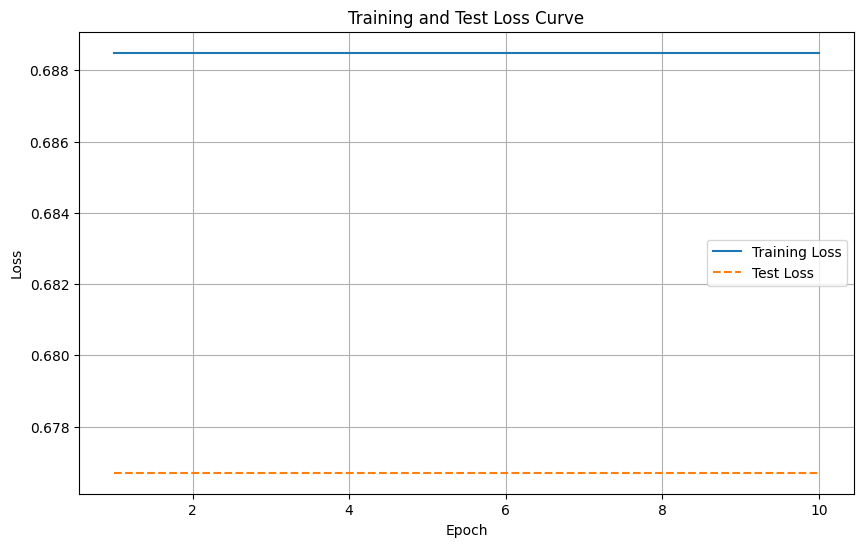

In [15]:
import torch.optim as optim

model_new_optimizer = ClassificationNet(input_units=30, hidden_units=64, output_units=2)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model_new_optimizer.parameters(), lr=0.001) # Here, change the optimizer to SGD

epochs = 10
train_losses = []
test_losses = []

for epoch in range(epochs):
    # Training phase
    model_new_optimizer.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model_new_optimizer(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Evaluation phase on test set
    model_new_optimizer.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            test_outputs = model_new_optimizer(X_batch)
            loss = criterion(test_outputs, y_batch)
            test_loss += loss.item()

    test_loss /= len(test_loader)
    test_losses.append(test_loss)

    print(f'Epoch [{epoch + 1}/{epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

import matplotlib.pyplot as plt

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
optimizer = optim.SGD(model_new_optimizer.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0001) # Here, change the optimizer to SGD

Exercise 2 - Change the number of neurons
Define a new neural network architecture with different neurons and see how it affects the model's performance.

Epoch [1/10], Train Loss: 0.3687, Test Loss: 0.2584
Epoch [2/10], Train Loss: 0.1484, Test Loss: 0.1743
Epoch [3/10], Train Loss: 0.1069, Test Loss: 0.1431
Epoch [4/10], Train Loss: 0.0903, Test Loss: 0.1257
Epoch [5/10], Train Loss: 0.0816, Test Loss: 0.1136
Epoch [6/10], Train Loss: 0.0761, Test Loss: 0.1061
Epoch [7/10], Train Loss: 0.0698, Test Loss: 0.1013
Epoch [8/10], Train Loss: 0.0652, Test Loss: 0.0974
Epoch [9/10], Train Loss: 0.0628, Test Loss: 0.0928
Epoch [10/10], Train Loss: 0.0580, Test Loss: 0.0920


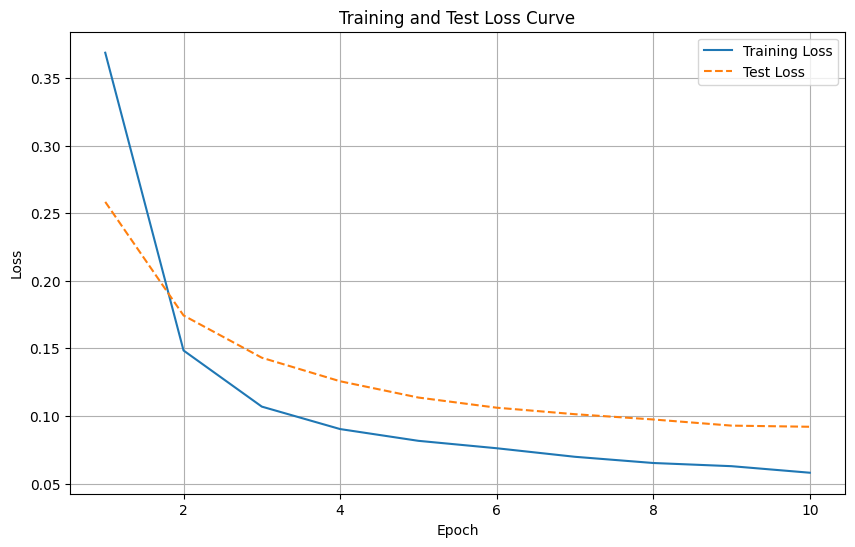

In [17]:
# Change the number of hidden units, e.g. 16.
model_new = ClassificationNet(input_units=30, hidden_units=32, output_units=2)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_new.parameters(), lr=0.001)

epochs = 10
train_losses = []
test_losses = []

for epoch in range(epochs):
    # Training phase
    model_new.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model_new(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Evaluation phase on test set
    model_new.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            test_outputs = model_new(X_batch)
            loss = criterion(test_outputs, y_batch)
            test_loss += loss.item()

    test_loss /= len(test_loader)
    test_losses.append(test_loss)

    print(f'Epoch [{epoch + 1}/{epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

import matplotlib.pyplot as plt

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
model_new = ClassificationNet(input_units=30, hidden_units=16, output_units=2)

Exercise 3 - Try different dataset - Iris Dataset
Try using the Iris dataset for classification. The Iris dataset is a classic dataset used for classification tasks. It contains 150 samples of iris flowers, each with 4 features. The dataset is divided into three classes, with each class representing a different species of iris flower. The goal is to classify the iris flowers into one of the three classes.

This dataset is free to use and is licensed under a Creative Commons Attribution 4.0 International (CC BY 4.0) license.

You can load the Iris dataset using the following code:

from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Extract the features and target variable
X_iris = iris.data
y_iris = iris.target
You can then preprocess the data, build and train the neural network model, and evaluate its performance on the test set.

Epoch [1/10], Train Loss: 1.2772, Test Loss: 1.1992
Epoch [2/10], Train Loss: 1.1536, Test Loss: 1.0909
Epoch [3/10], Train Loss: 1.0566, Test Loss: 1.0085
Epoch [4/10], Train Loss: 0.9742, Test Loss: 0.9357
Epoch [5/10], Train Loss: 0.8895, Test Loss: 0.8609
Epoch [6/10], Train Loss: 0.8011, Test Loss: 0.7810
Epoch [7/10], Train Loss: 0.7249, Test Loss: 0.7035
Epoch [8/10], Train Loss: 0.6416, Test Loss: 0.6343
Epoch [9/10], Train Loss: 0.5718, Test Loss: 0.5766
Epoch [10/10], Train Loss: 0.5152, Test Loss: 0.5301


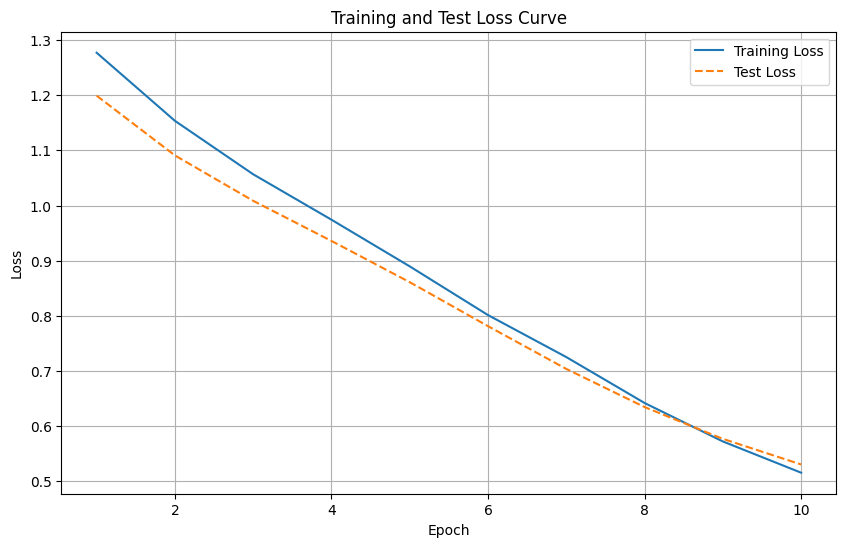

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()

# Extract the features and target variable
X_iris = iris.data
y_iris = iris.target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# Create DataLoader for training and test sets
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class IrisNet(nn.Module):
    def __init__(self, hidden_units=8):
        super(IrisNet, self).__init__()
        self.fc1 = nn.Linear(4, hidden_units)  # 4 input features for Iris dataset
        self.fc2 = nn.Linear(hidden_units, 3)  # 3 output classes for Iris dataset

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = IrisNet(hidden_units=8)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 10
train_losses = []
test_losses = []

for epoch in range(epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluation phase on test set
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            test_outputs = model(X_batch)
            loss = criterion(test_outputs, y_batch)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    print(f'Epoch [{epoch + 1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}')

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

Final Project: League of Legends Match Predictor
Introduction
League of Legends, a popular multiplayer online battle arena (MOBA) game, generates extensive data from matches, providing an excellent opportunity to apply machine learning techniques to real-world scenarios. Perform the following steps to build a logistic regression model aimed at predicting the outcomes of League of Legends matches.

Use the league_of_legends_data_large.csv file to perform the tasks.

Step 1: Data Loading and Preprocessing
Task 1: Load the League of Legends dataset and preprocess it for training.
Loading and preprocessing the dataset involves reading the data, splitting it into training and testing sets, and standardizing the features. You will utilize pandas for data manipulation, train_test_split from sklearn for data splitting, and StandardScaler for feature scaling.

Note: Please ensure all the required libraries are installed and imported.

1 .Load the dataset: Use pd.read_csv() to load the dataset into a pandas DataFrame.
2. Split data into features and target: Separate win (target) and the remaining columns (features).
X = data.drop('win', axis=1)
y = data['win']
3 .Split the Data into Training and Testing Sets: Use train_test_split() from sklearn.model_selection to divide the data. Set test_size=0.2 to allocate 20% for testing and 80% for training, and use random_state=42 to ensure reproducibility of the split.
4. Standardize the features: Use StandardScaler() from sklearn.preprocessing to scale the features.
5. Convert to PyTorch tensors: Use torch.tensor() to convert the data to PyTorch tensors.

Exercise 1:
Write a code to load the dataset, split it into training and testing sets, standardize the features, and convert the data into PyTorch tensors for use in training a PyTorch model.

Setup
Installing required libraries:

The following required libraries are not pre-installed in the Skills Network Labs environment. You will need to run the following cell to install them:



In [20]:
!pip install pandas
!pip install scikit-learn
!pip install torch
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 51.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [21]:
!pip install pandas numpy scikit-learn torch


In [24]:
import os
print(os.listdir())


['.config', 'sample_data']


In [29]:
import os
print(os.getcwd())  # Print the current working directory
print(os.listdir())  # List all files in the current directory


/content
['.config', 'sample_data']


In [32]:
file_path = "/content/drive/MyDrive/league_of_legends_data_large.csv"
data = pd.read_csv(file_path)


In [33]:
# Import necessary libraries
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
file_path = "/content/drive/MyDrive/league_of_legends_data_large.csv"  # Ensure the file is in the correct directory
data = pd.read_csv(file_path)

# Split into features (X) and target (y)
X = data.drop(columns=["win"])  # Drop the target column
y = data["win"]  # Target variable

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Print tensor shapes to verify
print("X_train shape:", X_train_tensor.shape)
print("X_test shape:", X_test_tensor.shape)
print("y_train shape:", y_train_tensor.shape)
print("y_test shape:", y_test_tensor.shape)


X_train shape: torch.Size([800, 8])
X_test shape: torch.Size([200, 8])
y_train shape: torch.Size([800, 1])
y_test shape: torch.Size([200, 1])


Step 2: Logistic Regression Model
Task 2: Implement a logistic regression model using PyTorch.
Defining the logistic regression model involves specifying the input dimensions, the forward pass using the sigmoid activation function, and initializing the model, loss function, and optimizer.

1 .Define the Logistic Regression Model:
Create a class LogisticRegressionModel that inherits from torch.nn.Module.

In the __init__() method, define a linear layer (nn.Linear) to implement the logistic regression model.
The forward() method should apply the sigmoid activation function to the output of the linear layer.
2.Initialize the Model, Loss Function, and Optimizer:

Set input_dim: Use X_train.shape[1] to get the number of features from the training data (X_train).
Initialize the model: Create an instance of the LogisticRegressionModel class (e.g., model = LogisticRegressionModel())while passing input_dim as a parameter
Loss Function: Use BCELoss() from torch.nn (Binary Cross-Entropy Loss).
Optimizer: Initialize the optimizer using optim.SGD() with a learning rate of 0.01
Exercise 2:
Define the logistic regression model using PyTorch, specifying the input dimensions and the forward pass. Initialize the model, loss function, and optimizer.

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the Logistic Regression Model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)  # Single neuron for binary classification

    def forward(self, x):
        return torch.sigmoid(self.linear(x))  # Sigmoid activation for probability output

# Get input dimensions
input_dim = X_train.shape[1]  # Number of features

# Initialize the Model
model = LogisticRegressionModel(input_dim)

# Define Loss Function (Binary Cross-Entropy)
criterion = nn.BCELoss()

# Define Optimizer (Stochastic Gradient Descent with learning rate 0.01)
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Print model summary
print(model)


LogisticRegressionModel(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)


Step 3: Model Training
Task 3: Train the logistic regression model on the dataset.
The training loop will run for a specified number of epochs. In each epoch, the model makes predictions, calculates the loss, performs backpropagation, and updates the model parameters.

Set Number of Epochs:

Define the number of epochs for training to 1000.
Training Loop:
For each epoch:

Set the model to training mode using model.train().
Zero the gradients using optimizer.zero_grad().
Pass the training data (X_train) through the model to get the predictions (outputs).
Calculate the loss using the defined loss function (criterion).
Perform backpropagation with loss.backward().
Update the model's weights using optimizer.step().
Print Loss Every 100 Epochs:

After every 100 epochs, print the current epoch number and the loss value.
Model Evaluation:

Set the model to evaluation mode using model.eval().
Use torch.no_grad() to ensure no gradients are calculated during evaluation.
Get predictions on both the training set (X_train) and the test set (X_test).
Calculate Accuracy:

For both the training and test datasets, compute the accuracy by comparing the predicted values with the true values (y_train, y_test).
Use a threshold of 0.5 for classification
Print Accuracy:

Print the training and test accuracies after the evaluation is complete.
Exercise 3:
Write the code to train the logistic regression model on the dataset. Implement the training loop, making predictions, calculating the loss, performing backpropagation, and updating model parameters. Evaluate the model's accuracy on training and testing sets.

In [37]:
# Training Loop
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    optimizer.zero_grad()  # Zero gradients to prevent accumulation

    # Forward pass - Get model predictions
    outputs = model(X_train_tensor) # Use X_train_tensor instead of X_train

    # Compute loss
    loss = criterion(outputs, y_train_tensor) # Use y_train_tensor instead of y_train

    # Backpropagation
    loss.backward()  # Compute gradients
    optimizer.step()  # Update weights

    # Print loss every 100 epochs
    if (epoch+1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Model Evaluation
model.eval()  # Set model to evaluation mode
with torch.no_grad():  # Disable gradient computation during inference
    train_preds = model(X_train_tensor) # Use X_train_tensor instead of X_train
    test_preds = model(X_test_tensor) # Use X_test_tensor instead of X_test

# Convert probabilities to binary (0 or 1) using threshold 0.5
train_preds = (train_preds >= 0.5).float()
test_preds = (test_preds >= 0.5).float()

# Compute Accuracy
train_accuracy = (train_preds.eq(y_train_tensor).sum() / y_train_tensor.shape[0]).item() * 100 # Use y_train_tensor instead of y_train
test_accuracy = (test_preds.eq(y_test_tensor).sum() / y_test_tensor.shape[0]).item() * 100 # Use y_test_tensor instead of y_test

# Print Accuracies
print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Epoch [100/1000], Loss: 0.7089
Epoch [200/1000], Loss: 0.6996
Epoch [300/1000], Loss: 0.6939
Epoch [400/1000], Loss: 0.6905
Epoch [500/1000], Loss: 0.6884
Epoch [600/1000], Loss: 0.6871
Epoch [700/1000], Loss: 0.6864
Epoch [800/1000], Loss: 0.6859
Epoch [900/1000], Loss: 0.6857
Epoch [1000/1000], Loss: 0.6855
Training Accuracy: 55.12%
Test Accuracy: 52.50%


In [36]:
import torch

# Convert DataFrame to NumPy arrays first
X_train_np = X_train.to_numpy().astype('float32')  # Convert DataFrame to float32 NumPy array
X_test_np = X_test.to_numpy().astype('float32')
y_train_np = y_train.to_numpy().astype('float32').reshape(-1, 1)  # Reshape for PyTorch
y_test_np = y_test.to_numpy().astype('float32').reshape(-1, 1)

# Convert NumPy arrays to PyTorch tensors
X_train = torch.tensor(X_train_np)
X_test = torch.tensor(X_test_np)
y_train = torch.tensor(y_train_np)
y_test = torch.tensor(y_test_np)


Step 4: Model Optimization and Evaluation¶
Task 4: Implement optimization techniques and evaluate the model's performance.
Optimization techniques such as L2 regularization (Ridge Regression) help in preventing overfitting. The model is retrained with these optimizations, and its performance is evaluated on both training and testing sets.

Weight Decay :In the context of machine learning and specifically in optimization algorithms, weight_decay is a parameter used to apply L2 regularization to the model's parameters (weights). It helps prevent the model from overfitting by penalizing large weight values, thereby encouraging the model to find simpler solutions.To use L2 regularization, you need to modify the optimizer by setting the weight_decay parameter. The weight_decay parameter in the optimizer adds the L2 regularization term during training. For example, when you initialize the optimizer with optim.SGD(model.parameters(), lr=0.01, weight_decay=0.01), the weight_decay=0.01 term applies L2 regularization with a strength of 0.01.

Set Up the Optimizer with L2 Regularization:

Modify the optimizer to include weight_decay for L2 regularization.
Example:
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.01)
Train the Model with L2 Regularization:

Follow the same steps as before but use the updated optimizer with regularization during training.
Use epochs=1000
Evaluate the Optimized Model:

After training, evaluate the model on both the training and test datasets.
Compute the accuracy for both sets by comparing the model's predictions to the true labels (y_train and y_test).
Calculate and Print the Accuracy:

Use a threshold of 0.5 to determine whether the model's predictions are class 0 or class 1.
Print the training accuracy and test accuracy after evaluation.
Exercise 4:
Implement optimization techniques like L2 regularization and retrain the model. Evaluate the performance of the optimized model on both training and testing sets.

In [38]:
import torch.optim as optim

# Initialize the optimizer with L2 regularization (weight_decay=0.01)
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.01)


In [39]:
num_epochs = 1000

for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    optimizer.zero_grad()  # Reset gradients

    outputs = model(X_train)  # Forward pass
    loss = criterion(outputs, y_train)  # Compute loss

    loss.backward()  # Backpropagation
    optimizer.step()  # Update model parameters

    # Print loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')


Epoch [100/1000], Loss: 49.3750
Epoch [200/1000], Loss: 49.3750
Epoch [300/1000], Loss: 49.3750
Epoch [400/1000], Loss: 49.3750
Epoch [500/1000], Loss: 49.3750
Epoch [600/1000], Loss: 49.3750
Epoch [700/1000], Loss: 49.3750
Epoch [800/1000], Loss: 49.3750
Epoch [900/1000], Loss: 49.3750
Epoch [1000/1000], Loss: 49.3750


In [40]:
# Set model to evaluation mode
model.eval()

with torch.no_grad():  # No gradient calculations needed during evaluation
    train_preds = model(X_train)
    test_preds = model(X_test)

    # Convert probabilities to binary predictions (threshold = 0.5)
    train_preds = (train_preds >= 0.5).float()
    test_preds = (test_preds >= 0.5).float()

    # Compute accuracy
    train_accuracy = (train_preds.eq(y_train).sum().item()) / y_train.shape[0]
    test_accuracy = (test_preds.eq(y_test).sum().item()) / y_test.shape[0]

print(f'Training Accuracy: {train_accuracy * 100:.2f}%')
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')


Training Accuracy: 50.62%
Test Accuracy: 52.50%


Step 5: Visualization and Interpretation
Visualization tools like confusion matrices and ROC curves provide insights into the model's performance. The confusion matrix helps in understanding the classification accuracy, while the ROC curve illustrates the trade-off between sensitivity and specificity.

Confusion Matrix : A Confusion Matrix is a fundamental tool used in classification problems to evaluate the performance of a model. It provides a matrix showing the number of correct and incorrect predictions made by the model, categorized by the actual and predicted classes. Where

True Positive (TP): Correctly predicted positive class (class 1).
True Negative (TN): Correctly predicted negative class (class 0).
False Positive (FP): Incorrectly predicted as positive (class 1), but the actual class is negative (class 0). This is also called a Type I error.
False Negative (FN): Incorrectly predicted as negative (class 0), but the actual class is positive (class 1). This is also called a Type II error.
ROC Curve (Receiver Operating Characteristic Curve): The ROC Curve is a graphical representation used to evaluate the performance of a binary classification model across all classification thresholds. It plots two metrics:

True Positive Rate (TPR) or Recall (Sensitivity)-It is the proportion of actual positive instances (class 1) that were correctly classified as positive by the model.
False Positive Rate (FPR)-It is the proportion of actual negative instances (class 0) that were incorrectly classified as positive by the model.
AUC: AUC stands for Area Under the Curve and is a performance metric used to evaluate the quality of a binary classification model. Specifically, it refers to the area under the ROC curve (Receiver Operating Characteristic curve), which plots the True Positive Rate (TPR) versus the False Positive Rate (FPR) for different threshold values.

Classification Report: A Classification Report is a summary of various classification metrics, which are useful for evaluating the performance of a classifier on the given dataset.

Exercise 5:
Write code to visualize the model's performance using confusion matrices and ROC curves. Generate classification reports to evaluate precision, recall, and F1-score. Retrain the model with L2 regularization and evaluate the performance.

In [42]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Ensure model is in evaluation mode
model.eval()

with torch.no_grad():
    y_train_pred = model(X_train)
    y_test_pred = model(X_test)

# Convert probabilities to binary predictions
y_train_pred_binary = (y_train_pred >= 0.5).float()
y_test_pred_binary = (y_test_pred >= 0.5).float()


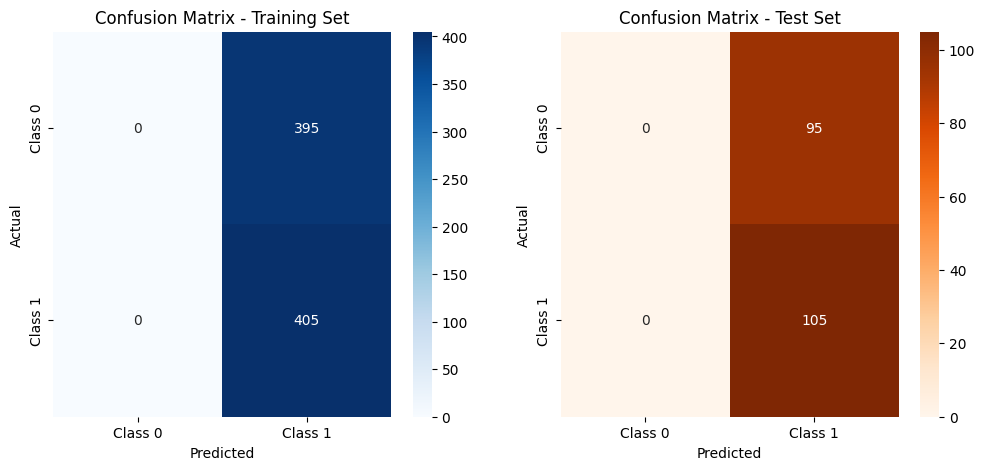

In [43]:
# Convert tensors to NumPy arrays
y_train_np = y_train.numpy()
y_test_np = y_test.numpy()
y_train_pred_np = y_train_pred_binary.numpy()
y_test_pred_np = y_test_pred_binary.numpy()

# Compute confusion matrices
train_cm = confusion_matrix(y_train_np, y_train_pred_np)
test_cm = confusion_matrix(y_test_np, y_test_pred_np)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Training Set')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(test_cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'], ax=axes[1])
axes[1].set_title('Confusion Matrix - Test Set')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.show()


In [44]:
print("Classification Report - Training Set:\n", classification_report(y_train_np, y_train_pred_np))
print("Classification Report - Test Set:\n", classification_report(y_test_np, y_test_pred_np))


Classification Report - Training Set:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       395
         1.0       0.51      1.00      0.67       405

    accuracy                           0.51       800
   macro avg       0.25      0.50      0.34       800
weighted avg       0.26      0.51      0.34       800

Classification Report - Test Set:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        95
         1.0       0.53      1.00      0.69       105

    accuracy                           0.53       200
   macro avg       0.26      0.50      0.34       200
weighted avg       0.28      0.53      0.36       200



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _, _, f, _ = precision_recall_fscore_support(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _, _, f, _ = precision_recall_fscore_support(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _, _, f, _ = precision_recall_fscore_support(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-de

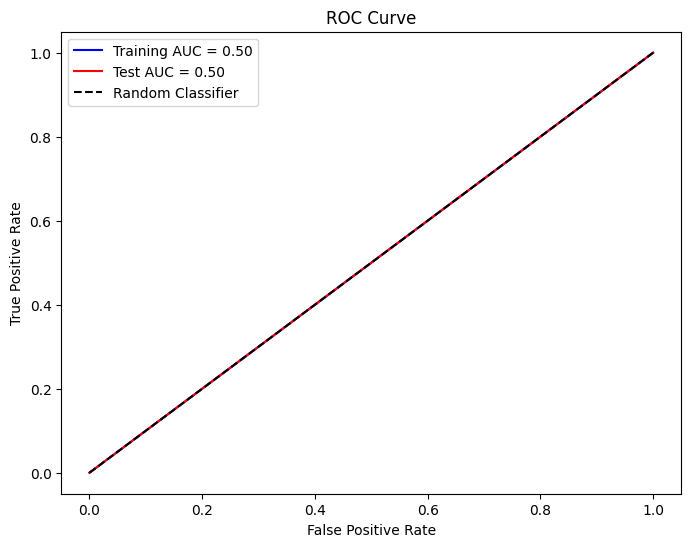

In [45]:
# Compute ROC curve
fpr_train, tpr_train, _ = roc_curve(y_train_np, y_train_pred.numpy())
fpr_test, tpr_test, _ = roc_curve(y_test_np, y_test_pred.numpy())

# Compute AUC
auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Training AUC = {auc_train:.2f}', color='blue')
plt.plot(fpr_test, tpr_test, label=f'Test AUC = {auc_test:.2f}', color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')  # Random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


Step 6: Model Saving and Loading
Task 6: Save and load the trained model.
This task demonstrates the techniques to persist a trained model using torch.save and reload it using torch.load. Evaluating the loaded model ensures that it retains its performance, making it practical for deployment in real-world applications.

Saving the Model:
Save the model's learned weights and biases using torch.save().( e.g. , torch.save(model.state_dict(), 'your_model_name.pth'))
Saving only the state dictionary (model parameters) is preferred because it’s more flexible and efficient than saving the entire model object.
Loading the Model:
Create a new model instance (e.g., model = LogisticRegressionModel()) and load the saved parameters. ( e.g. , model.load_state_dict(torch.load('your_model_name.pth'))).
Evaluating the Loaded Model:
After loading, set the model to evaluation mode by calling model.eval()
After loading the model, evaluate it again on the test dataset to make sure it performs similarly to when it was first trained..Now evaluate it on the test data.
Use torch.no_grad() to ensure that no gradients are computed.
Exercise 6:
Write code to save the trained model and reload it. Ensure the loaded model performs consistently by evaluating it on the test dataset.

In [46]:
import torch

# Save the model parameters (state_dict)
torch.save(model.state_dict(), 'logistic_regression_model.pth')

print("Model saved successfully!")


Model saved successfully!


In [47]:
# Create a new model instance
loaded_model = LogisticRegressionModel(input_dim=X_train.shape[1])

# Load the saved model parameters
loaded_model.load_state_dict(torch.load('logistic_regression_model.pth'))

# Set the model to evaluation mode
loaded_model.eval()

print("Model loaded successfully!")


Model loaded successfully!


<ipython-input-47-c983d25c8c26>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('logistic_regression_model.pth'))


In [48]:
# Evaluate performance using test data
with torch.no_grad():
    y_test_loaded_pred = loaded_model(X_test)

# Convert predictions to binary (0 or 1)
y_test_loaded_pred_binary = (y_test_loaded_pred >= 0.5).float()

# Compute accuracy
accuracy = (y_test_loaded_pred_binary == y_test).float().mean().item()

print(f"Loaded Model Test Accuracy: {accuracy * 100:.2f}%")


Loaded Model Test Accuracy: 52.50%


Step 7: Hyperparameter Tuning
Task 7: Perform hyperparameter tuning to find the best learning rate.
By testing different learning rates, you will identify the optimal rate that provides the best test accuracy. This fine-tuning is crucial for enhancing model performance .

Define Learning Rates:

Choose these learning rates to test ,[0.01, 0.05, 0.1]
Reinitialize the Model for Each Learning Rate:

For each learning rate, you’ll need to reinitialize the model and optimizer e.g.(torch.optim.SGD(model.parameters(), lr=lr)).
Each new learning rate requires reinitializing the model since the optimizer and its parameters are linked to the learning rate.
Train the Model for Each Learning Rate:
Train the model for a fixed number of epochs (e.g., 50 or 100 epochs) for each learning rate, and compute the accuracy on the test set.
Track the test accuracy for each learning rate and identify which one yields the best performance.
Evaluate and Compare:
After training with each learning rate, compare the test accuracy for each configuration.
Report the learning rate that gives the highest test accuracy
Exercise 7:
Perform hyperparameter tuning to find the best learning rate. Retrain the model for each learning rate and evaluate its performance to identify the optimal rate.

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim

# List of learning rates to test
learning_rates = [0.01, 0.05, 0.1]
num_epochs = 100  # Fixed number of epochs
best_lr = None
best_accuracy = 0
results = {}

# Function to train and evaluate the model
def train_and_evaluate(lr):
    # Reinitialize model
    model = LogisticRegressionModel(input_dim=X_train.shape[1])

    # Loss function
    criterion = nn.BCELoss()

    # Optimizer with current learning rate
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X_train)

        # Compute loss
        loss = criterion(outputs, y_train)

        # Backpropagation
        loss.backward()
        optimizer.step()

    # Evaluate model on test set
    model.eval()
    with torch.no_grad():
        y_test_pred = model(X_test)

    # Convert predictions to binary
    y_test_pred_binary = (y_test_pred >= 0.5).float()

    # Calculate accuracy
    accuracy = (y_test_pred_binary == y_test).float().mean().item()

    print(f"Learning Rate: {lr}, Test Accuracy: {accuracy * 100:.2f}%")

    return accuracy

# Iterate through different learning rates
for lr in learning_rates:
    accuracy = train_and_evaluate(lr)
    results[lr] = accuracy

    # Update best learning rate
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_lr = lr

# Print the best learning rate
print(f"\nBest Learning Rate: {best_lr}, Best Test Accuracy: {best_accuracy * 100:.2f}%")


Learning Rate: 0.01, Test Accuracy: 52.50%
Learning Rate: 0.05, Test Accuracy: 47.50%
Learning Rate: 0.1, Test Accuracy: 47.50%

Best Learning Rate: 0.01, Best Test Accuracy: 52.50%


Step 8: Feature Importance
Task 8: Evaluate feature importance to understand the impact of each feature on the prediction.
The code to evaluate feature importance to understand the impact of each feature on the prediction.

1.Extracting Model Weights:

The weights of the logistic regression model represent the importance of each feature in making predictions. These weights are stored in the model's linear layer (model.linear.weight).
You can extract the weights using model.linear.weight.data.numpy() and flatten the resulting tensor to get a 1D array of feature importances.
2.Creating a DataFrame:

Create a pandas DataFrame with two columns: one for the feature names and the other for their corresponding importance values (i.e., the learned weights).
Ensure the features are aligned with their names in your dataset (e.g., `X_train.columns).
Sorting and Plotting Feature Importance:
Sort the features based on the absolute value of their importance (weights) to identify the most impactful features.
Use a bar plot (via matplotlib) to visualize the sorted feature importances, with the feature names on the y-axis and importance values on the x-axis.
Interpreting the Results:
Larger absolute weights indicate more influential features. Positive weights suggest a positive correlation with the outcome (likely to predict the positive class), while negative weights suggest the opposite.
Exercise 8:
Evaluate feature importance by extracting the weights of the linear layer and creating a DataFrame to display the importance of each feature. Visualize the feature importance using a bar plot.

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get the original feature names from 'X' before it was converted to a tensor
original_feature_names = X.columns  # Assuming 'X' is your original DataFrame

# Extract model weights
weights = model.linear.weight.data.numpy().flatten()

# Create a DataFrame to store feature names and importance values
feature_importance = pd.DataFrame({
    "Feature": original_feature_names,  # Use original feature names
    "Importance": weights
})

# Sort features based on absolute importance
feature_importance = feature_importance.reindex(feature_importance["Importance"].abs().sort_values(ascending=False).index)

# Display feature importance
print(feature_importance)

        Feature  Importance
7  damage_dealt    0.592906
3   gold_earned    0.264710
5  wards_placed    0.093064
0         kills    0.092133
6  wards_killed   -0.023603
2       assists    0.005125
1        deaths    0.001935
4            cs    0.001061


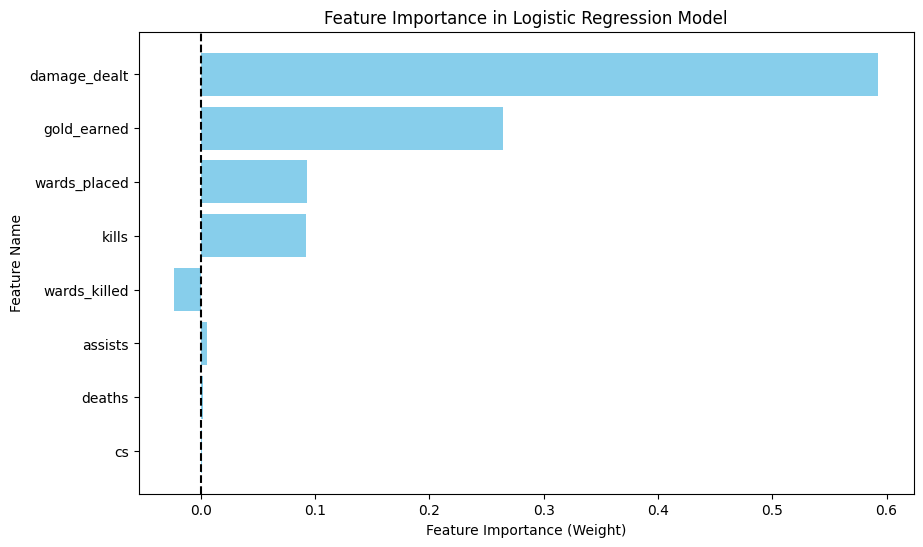

In [53]:
# Bar plot of feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"], color='skyblue')
plt.xlabel("Feature Importance (Weight)")
plt.ylabel("Feature Name")
plt.title("Feature Importance in Logistic Regression Model")
plt.axvline(x=0, color="black", linestyle="dashed")  # Line at zero for reference
plt.gca().invert_yaxis()  # Invert y-axis to show most important features on top
plt.show()
